# Project 3: Build `light_Data.csv` with Aggregated Quarterly Night-Light Data

This notebook creates the cleaned CSV for the D3 visualization.

**Goal:** `1 row = 1 year + 1 quarter`, where each quarter is aggregated from monthly satellite images.

So instead of one dot being one random day, each dot later represents a **3-month seasonal average**:

- Q1 = Jan-Mar
- Q2 = Apr-Jun
- Q3 = Jul-Sep
- Q4 = Oct-Dec

The final output is:

```text
light_Data.csv
```


In [6]:
import io
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)


## 1. NASA GIBS WMS setup

This fetches NASA GIBS imagery using WMS. The bounding box below focuses on the continental United States.

In [7]:
GIBS_WMS_ENDPOINT = "https://gibs.earthdata.nasa.gov/wms/epsg4326/best/wms.cgi"

# Continental United States bounding box: west, south, east, north
REGION_BBOX = (-125, 24, -66, 50)
REGION_NAME = "Continental United States"

# Nighttime lights layer
LAYER_TO_USE = "VIIRS_SNPP_DayNightBand"


def fetch_gibs_wms_image(
    layer,
    date,
    bbox=REGION_BBOX,
    width=900,
    height=450,
    image_format="image/png",
):
    # Fetch one NASA GIBS WMS image for a layer/date/bounding box.
    params = {
        "SERVICE": "WMS",
        "REQUEST": "GetMap",
        "VERSION": "1.1.1",
        "LAYERS": layer,
        "STYLES": "",
        "SRS": "EPSG:4326",
        "BBOX": ",".join(map(str, bbox)),
        "WIDTH": width,
        "HEIGHT": height,
        "FORMAT": image_format,
        "TRANSPARENT": "TRUE",
        "TIME": date,
    }

    response = requests.get(GIBS_WMS_ENDPOINT, params=params, timeout=60)
    response.raise_for_status()

    content_type = response.headers.get("Content-Type", "")
    if "image" not in content_type.lower():
        raise ValueError(f"Expected image response, got {content_type}: {response.text[:300]}")

    return Image.open(io.BytesIO(response.content)).convert("RGBA")


def image_to_rgb_array(img):
    # Convert PIL image to RGB array normalized to 0-1.
    arr = np.asarray(img).astype(float) / 255.0
    return arr[:, :, :3]


## 2. Build monthly sample dates

We sample one image per month, then aggregate those monthly values into quarterly averages.

In [8]:
import calendar
import random

random.seed(106)  # keeps the random days reproducible

years = list(range(2013, 2027))

months = [
    {"month": 1, "month_label": "Jan", "quarter": 1, "quarter_label": "Jan-Mar"},
    {"month": 2, "month_label": "Feb", "quarter": 1, "quarter_label": "Jan-Mar"},
    {"month": 3, "month_label": "Mar", "quarter": 1, "quarter_label": "Jan-Mar"},

    {"month": 4, "month_label": "Apr", "quarter": 2, "quarter_label": "Apr-Jun"},
    {"month": 5, "month_label": "May", "quarter": 2, "quarter_label": "Apr-Jun"},
    {"month": 6, "month_label": "Jun", "quarter": 2, "quarter_label": "Apr-Jun"},

    {"month": 7, "month_label": "Jul", "quarter": 3, "quarter_label": "Jul-Sep"},
    {"month": 8, "month_label": "Aug", "quarter": 3, "quarter_label": "Jul-Sep"},
    {"month": 9, "month_label": "Sep", "quarter": 3, "quarter_label": "Jul-Sep"},

    {"month": 10, "month_label": "Oct", "quarter": 4, "quarter_label": "Oct-Dec"},
    {"month": 11, "month_label": "Nov", "quarter": 4, "quarter_label": "Oct-Dec"},
    {"month": 12, "month_label": "Dec", "quarter": 4, "quarter_label": "Oct-Dec"},
]

sample_dates = []

for year in years:
    for m in months:
        month = m["month"]

        # number of days in this month
        _, days_in_month = calendar.monthrange(year, month)

        # pick 7 unique random days from the month
        random_days = sorted(random.sample(range(1, days_in_month + 1), 7))

        for sample_id, day in enumerate(random_days, start=1):
            sample_dates.append({
                "date": f"{year}-{month:02d}-{day:02d}",
                "year": year,
                "month": month,
                "month_label": m["month_label"],
                "quarter": m["quarter"],
                "quarter_label": m["quarter_label"],
                "sample_id": sample_id
            })

sample_dates[:14]

[{'date': '2013-01-01',
  'year': 2013,
  'month': 1,
  'month_label': 'Jan',
  'quarter': 1,
  'quarter_label': 'Jan-Mar',
  'sample_id': 1},
 {'date': '2013-01-16',
  'year': 2013,
  'month': 1,
  'month_label': 'Jan',
  'quarter': 1,
  'quarter_label': 'Jan-Mar',
  'sample_id': 2},
 {'date': '2013-01-17',
  'year': 2013,
  'month': 1,
  'month_label': 'Jan',
  'quarter': 1,
  'quarter_label': 'Jan-Mar',
  'sample_id': 3},
 {'date': '2013-01-18',
  'year': 2013,
  'month': 1,
  'month_label': 'Jan',
  'quarter': 1,
  'quarter_label': 'Jan-Mar',
  'sample_id': 4},
 {'date': '2013-01-23',
  'year': 2013,
  'month': 1,
  'month_label': 'Jan',
  'quarter': 1,
  'quarter_label': 'Jan-Mar',
  'sample_id': 5},
 {'date': '2013-01-29',
  'year': 2013,
  'month': 1,
  'month_label': 'Jan',
  'quarter': 1,
  'quarter_label': 'Jan-Mar',
  'sample_id': 6},
 {'date': '2013-01-30',
  'year': 2013,
  'month': 1,
  'month_label': 'Jan',
  'quarter': 1,
  'quarter_label': 'Jan-Mar',
  'sample_id': 7},

## 3. Fetch monthly images

This will try to fetch 168 images: `14 years x 12 months`.

If a few fail, the notebook will continue. The `months_included` column later will show how many monthly images were used for each quarter.

In [9]:
images = {}
failed_dates = []

for d in sample_dates:
    date = d["date"]
    start = time.time()

    try:
        img = fetch_gibs_wms_image(
            layer=LAYER_TO_USE,
            date=date,
            bbox=REGION_BBOX,
            width=900,
            height=450,
            image_format="image/png",
        )

        images[date] = img
        print(f"Fetched {date} in {time.time() - start:.2f}s")

    except Exception as e:
        failed_dates.append({"date": date, "error": str(e)})
        print(f"Skipped {date}: {e}")

print("Total images fetched:", len(images))
print("Total failed:", len(failed_dates))


Fetched 2013-01-01 in 0.86s
Fetched 2013-01-16 in 0.92s
Fetched 2013-01-17 in 0.98s
Fetched 2013-01-18 in 0.86s
Fetched 2013-01-23 in 0.98s
Fetched 2013-01-29 in 0.92s
Fetched 2013-01-30 in 0.85s
Fetched 2013-02-02 in 1.52s
Fetched 2013-02-03 in 1.83s
Fetched 2013-02-07 in 0.97s
Fetched 2013-02-09 in 1.01s
Fetched 2013-02-12 in 1.00s
Fetched 2013-02-16 in 0.85s
Fetched 2013-02-26 in 1.10s
Fetched 2013-03-08 in 0.84s
Fetched 2013-03-10 in 1.00s
Fetched 2013-03-14 in 0.85s
Fetched 2013-03-15 in 0.81s
Fetched 2013-03-21 in 1.01s
Fetched 2013-03-23 in 0.84s
Fetched 2013-03-24 in 0.90s
Fetched 2013-04-05 in 1.22s
Fetched 2013-04-09 in 1.03s
Fetched 2013-04-15 in 0.84s
Fetched 2013-04-16 in 0.92s
Fetched 2013-04-21 in 1.15s
Fetched 2013-04-23 in 1.11s
Fetched 2013-04-24 in 0.89s
Fetched 2013-05-03 in 1.15s
Fetched 2013-05-06 in 1.13s
Fetched 2013-05-09 in 0.82s
Fetched 2013-05-10 in 0.77s
Fetched 2013-05-12 in 0.85s
Fetched 2013-05-16 in 0.90s
Fetched 2013-05-29 in 0.76s
Fetched 2013-06-03 i

In [36]:
# Optional: inspect failed dates if any
pd.DataFrame(failed_dates).head(20)


""


## 4. Convert each monthly image into brightness metrics

Each monthly image becomes one row in `monthly_df`.

Brightness is calculated as the average of RGB channels, and `bright_pixel_ratio` is the fraction of pixels above the brightness threshold.

In [37]:
glow_threshold = 0.35

date_lookup = {d["date"]: d for d in sample_dates}
monthly_rows = []

for date, img in images.items():
    arr = image_to_rgb_array(img)

    brightness = arr.mean(axis=2)
    bright_mask = brightness > glow_threshold

    info = date_lookup[date]

    monthly_rows.append({
        "date": date,
        "year": info["year"],
        "month": info["month"],
        "month_label": info["month_label"],
        "quarter": info["quarter"],
        "quarter_label": info["quarter_label"],
        "sample_id": info["sample_id"],
        "mean_brightness": float(brightness.mean()),
        "median_brightness": float(np.median(brightness)),
        "max_brightness": float(brightness.max()),
        "bright_pixel_ratio": float(bright_mask.mean()),
    })

monthly_df = pd.DataFrame(monthly_rows).sort_values(["year", "month"])
print("Monthly rows:", monthly_df.shape)
monthly_df.head(12)


Monthly rows: (1176, 11)


,date,year,month,month_label,quarter,quarter_label,sample_id,mean_brightness,median_brightness,max_brightness,bright_pixel_ratio
0,2013-01-01,2013,1,Jan,1,Jan-Mar,1,0.715128,0.811765,0.996078,0.861790
1,2013-01-16,2013,1,Jan,1,Jan-Mar,2,0.588250,0.650980,0.996078,0.740652
2,2013-01-17,2013,1,Jan,1,Jan-Mar,3,0.609049,0.627451,0.996078,0.848370
3,2013-01-18,2013,1,Jan,1,Jan-Mar,4,0.644032,0.682353,0.996078,0.867556
4,2013-01-23,2013,1,Jan,1,Jan-Mar,5,0.593979,0.564706,0.996078,0.821780
5,2013-01-29,2013,1,Jan,1,Jan-Mar,6,0.652944,0.760784,0.996078,0.788867
6,2013-01-30,2013,1,Jan,1,Jan-Mar,7,0.649361,0.776471,0.996078,0.771901
7,2013-02-02,2013,2,Feb,1,Jan-Mar,1,0.492755,0.466667,0.996078,0.644390
8,2013-02-03,2013,2,Feb,1,Jan-Mar,2,0.464638,0.411765,0.996078,0.594499
9,2013-02-07,2013,2,Feb,1,Jan-Mar,3,0.443874,0.388235,0.996078,0.566370


In [38]:
monthly_agg = (
    monthly_df
    .groupby(["year", "month", "month_label", "quarter", "quarter_label"], as_index=False)
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        days_sampled=("date", "count"),
        mean_brightness=("mean_brightness", "mean"),
        max_brightness=("max_brightness", "max"),
        bright_pixel_ratio=("bright_pixel_ratio", "mean")
    )
)

monthly_agg = monthly_agg.sort_values(["year", "month"])
monthly_agg.head(12)

,year,month,month_label,quarter,quarter_label,start_date,end_date,days_sampled,mean_brightness,max_brightness,bright_pixel_ratio
0,2013,1,Jan,1,Jan-Mar,2013-01-01,2013-01-30,7,0.636106,0.996078,0.814417
1,2013,2,Feb,1,Jan-Mar,2013-02-02,2013-02-26,7,0.495693,0.996078,0.642323
2,2013,3,Mar,1,Jan-Mar,2013-03-08,2013-03-24,7,0.491012,0.996078,0.645376
3,2013,4,Apr,2,Apr-Jun,2013-04-05,2013-04-24,7,0.439729,0.996078,0.561062
4,2013,5,May,2,Apr-Jun,2013-05-03,2013-05-29,7,0.486183,0.996078,0.644552
5,2013,6,Jun,2,Apr-Jun,2013-06-03,2013-06-27,7,0.591143,0.996078,0.839161
6,2013,7,Jul,3,Jul-Sep,2013-07-02,2013-07-29,7,0.584626,0.996078,0.790056
7,2013,8,Aug,3,Jul-Sep,2013-08-10,2013-08-26,7,0.464424,0.996078,0.620481
8,2013,9,Sep,3,Jul-Sep,2013-09-05,2013-09-20,7,0.377530,0.996078,0.439559
9,2013,10,Oct,4,Oct-Dec,2013-10-05,2013-10-30,7,0.595101,0.996078,0.828721


## 5. Aggregate monthly rows into quarterly rows

This creates the final D3-ready dataset.

Each row now means:

```text
one dot = one quarter = average of up to 3 monthly samples
```

In [39]:
light_Data = (
    monthly_agg
    .groupby(["year", "quarter", "quarter_label"], as_index=False)
    .agg(
        start_date=("start_date", "min"),
        end_date=("end_date", "max"),
        months_included=("month", "count"),
        total_days_sampled=("days_sampled", "sum"),
        mean_brightness=("mean_brightness", "mean"),
        max_brightness=("max_brightness", "max"),
        bright_pixel_ratio=("bright_pixel_ratio", "mean")
    )
)

light_Data = light_Data.sort_values(["year", "quarter"])
light_Data.head(12)

,year,quarter,quarter_label,start_date,end_date,months_included,total_days_sampled,mean_brightness,max_brightness,bright_pixel_ratio
0,2013,1,Jan-Mar,2013-01-01,2013-03-24,3,21,0.540937,0.996078,0.700705
1,2013,2,Apr-Jun,2013-04-05,2013-06-27,3,21,0.505685,0.996078,0.681592
2,2013,3,Jul-Sep,2013-07-02,2013-09-20,3,21,0.475526,0.996078,0.616699
3,2013,4,Oct-Dec,2013-10-05,2013-12-31,3,21,0.582679,0.996078,0.780324
4,2014,1,Jan-Mar,2014-01-07,2014-03-30,3,21,0.526365,0.996078,0.682755
5,2014,2,Apr-Jun,2014-04-02,2014-06-30,3,21,0.493612,0.996078,0.656378
6,2014,3,Jul-Sep,2014-07-04,2014-09-24,3,21,0.444554,0.996078,0.585544
7,2014,4,Oct-Dec,2014-10-01,2014-12-29,3,21,0.513070,0.996078,0.680385
8,2015,1,Jan-Mar,2015-01-01,2015-03-27,3,21,0.535793,0.996078,0.723315
9,2015,2,Apr-Jun,2015-04-02,2015-06-26,3,21,0.488437,0.996078,0.632125


## 6. Quality checks

Ideally, every quarter should have `months_included = 3`.

If some quarters have 1 or 2, those quarters still work, but they are based on fewer successful monthly images.

In [40]:
light_Data["months_included"].value_counts().sort_index()

months_included
3    56
Name: count, dtype: int64

In [41]:
# Look at any quarters with fewer than 3 months included
light_Data[light_Data["months_included"] < 3]


,year,quarter,quarter_label,start_date,end_date,months_included,total_days_sampled,mean_brightness,max_brightness,bright_pixel_ratio


In [43]:
light_Data.drop(light_Data.tail(3).index, inplace=True)

In [44]:
light_Data.tail()

,year,quarter,quarter_label,start_date,end_date,months_included,total_days_sampled,mean_brightness,max_brightness,bright_pixel_ratio
48,2025,1,Jan-Mar,2025-01-02,2025-03-30,3,21,0.517047,0.996078,0.703735
49,2025,2,Apr-Jun,2025-04-05,2025-06-27,3,21,0.508033,0.996078,0.662511
50,2025,3,Jul-Sep,2025-07-04,2025-09-29,3,21,0.477731,0.996078,0.670549
51,2025,4,Oct-Dec,2025-10-03,2025-12-29,3,21,0.502265,0.996078,0.689481
52,2026,1,Jan-Mar,2026-01-02,2026-03-29,3,21,0.477334,0.996078,0.647663


## 7. Quick preview plot

This is just to confirm the data looks reasonable before using it in D3.

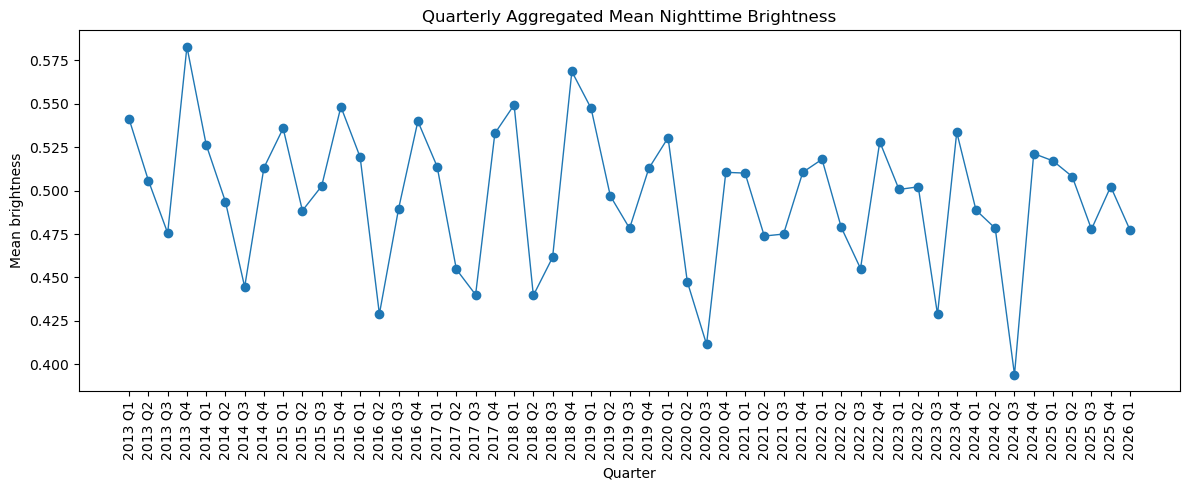

In [45]:
plt.figure(figsize=(12, 5))

x_labels = light_Data["year"].astype(str) + " Q" + light_Data["quarter"].astype(str)

plt.plot(x_labels, light_Data["mean_brightness"], marker="o", linewidth=1)
plt.xticks(rotation=90)
plt.title("Quarterly Aggregated Mean Nighttime Brightness")
plt.xlabel("Quarter")
plt.ylabel("Mean brightness")
plt.tight_layout()
plt.show()


## 8. Export final CSV

This file is what your D3 visualization should load.

In [46]:
light_Data.to_csv("light_Data.csv", index=False)

print("Saved light_Data.csv")
pd.read_csv("light_Data.csv").head()


Saved light_Data.csv


,year,quarter,quarter_label,start_date,end_date,months_included,total_days_sampled,mean_brightness,max_brightness,bright_pixel_ratio
0,2013,1,Jan-Mar,2013-01-01,2013-03-24,3,21,0.540937,0.996078,0.700705
1,2013,2,Apr-Jun,2013-04-05,2013-06-27,3,21,0.505685,0.996078,0.681592
2,2013,3,Jul-Sep,2013-07-02,2013-09-20,3,21,0.475526,0.996078,0.616699
3,2013,4,Oct-Dec,2013-10-05,2013-12-31,3,21,0.582679,0.996078,0.780324
4,2014,1,Jan-Mar,2014-01-07,2014-03-30,3,21,0.526365,0.996078,0.682755


## D3 meaning

Use this file in D3 as:

```js
d3.csv("data/light_Data.csv", d3.autoType)
```

Visual encoding idea:

- `year` = ring
- `quarter` = angle around the circle
- `mean_brightness` = color
- `bright_pixel_ratio` = dot size
- tooltip = `quarter_label`, `year`, `mean_brightness`, `bright_pixel_ratio`, `months_included`


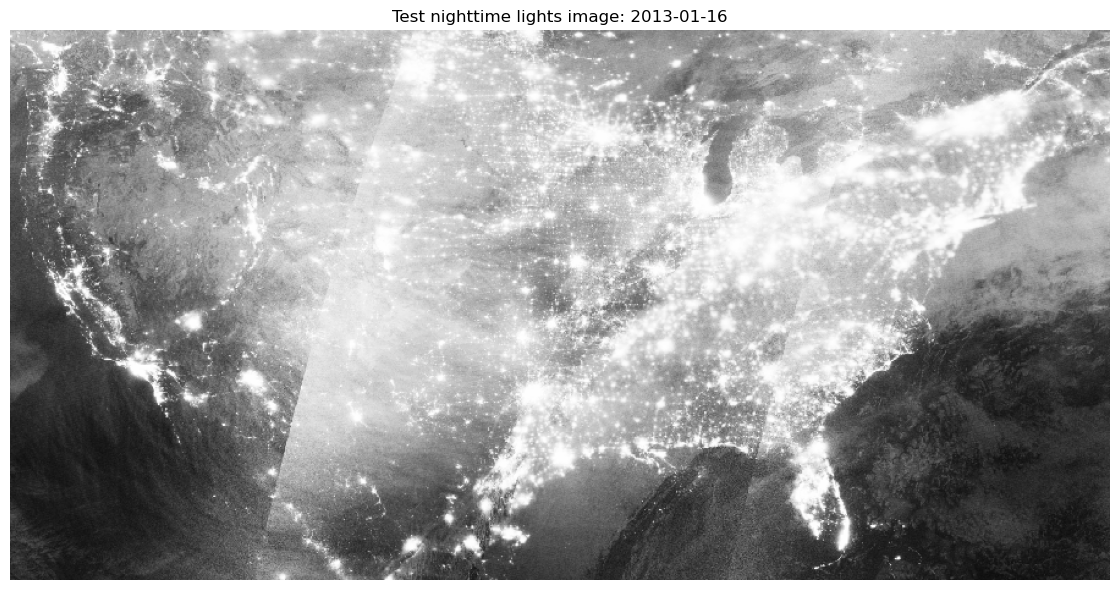

In [53]:
def show_gibs_image(img, title):
    plt.figure(figsize=(12, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

test_img = fetch_gibs_wms_image(
    layer=LAYER_TO_USE,
    date=test_date,
    bbox=REGION_BBOX,
    width=900,
    height=450,
    image_format="image/png",
)

show_gibs_image(test_img, f"Test nighttime lights image: {test_date}")

In [48]:
last_value = list(images.keys())[-1]
last_value

'2026-12-29'

In [52]:
test_date = '2013-01-16'